In [1]:
import pandas as pd

data= pd.read_csv("train_clean.csv")
print(data.head())

   bip_id   game_date home_team away_team batter_team        batter_name  \
0       1  2020-08-26       ARI       COL         COL     arenado, nolan   
1       2  2020-08-10       COL       ARI         COL     arenado, nolan   
2       3  2020-08-10       COL       ARI         COL     arenado, nolan   
3       4  2020-08-26       ARI       COL         COL  blackmon, charlie   
4       5  2020-08-10       COL       ARI         COL  blackmon, charlie   

  pitcher_name  batter_id  pitcher_id  is_batter_lefty  ...  inning  \
0  ray, robbie     571448      592662                0  ...       1   
1  ray, robbie     571448      592662                0  ...       1   
2  ray, robbie     571448      592662                0  ...       3   
3  ray, robbie     453568      592662                1  ...       1   
4  ray, robbie     453568      592662                1  ...       1   

  outs_when_up balls strikes  plate_x  plate_z  pitch_mph  launch_speed  \
0            0     1       2    -0.15    

In [2]:
data.duplicated().sum()

0

In [3]:
print(data.shape)
data.isna().sum()

(46244, 25)


bip_id                  0
game_date               0
home_team               0
away_team               0
batter_team             0
batter_name             0
pitcher_name            0
batter_id               0
pitcher_id              0
is_batter_lefty         0
is_pitcher_lefty        0
bb_type                 6
bearing                 0
pitch_name              0
park                    0
inning                  0
outs_when_up            0
balls                   0
strikes                 0
plate_x                 0
plate_z                 0
pitch_mph               0
launch_speed        11805
launch_angle        11785
is_home_run             0
dtype: int64

In [4]:
bball_model = data.dropna(subset=["launch_speed", "launch_angle"]).copy()

bball_model["bb_type"] = bball_model["bb_type"].fillna("Unknown")

In [5]:
print(bball_model.shape)
bball_model.isna().sum()

(25866, 25)


bip_id              0
game_date           0
home_team           0
away_team           0
batter_team         0
batter_name         0
pitcher_name        0
batter_id           0
pitcher_id          0
is_batter_lefty     0
is_pitcher_lefty    0
bb_type             0
bearing             0
pitch_name          0
park                0
inning              0
outs_when_up        0
balls               0
strikes             0
plate_x             0
plate_z             0
pitch_mph           0
launch_speed        0
launch_angle        0
is_home_run         0
dtype: int64

In [6]:
dropped_low_variance = []
dropped_high_cardinality = []

for col in bball_model.columns:
    if bball_model[col].nunique() <= 1:
        dropped_low_variance.append(col)

for col in bball_model.columns:
    if bball_model[col].nunique() == len(bball_model):
        dropped_high_cardinality.append(col)

# Now actually drop them
bball_model = bball_model.drop(columns=dropped_low_variance + dropped_high_cardinality)

cols_to_drop = ["batter_id", "pitcher_id", "batter_name", "pitcher_name", "game_date"]
bball_model = bball_model.drop(columns=cols_to_drop, errors="ignore")

print("Low variance dropped:", dropped_low_variance)
print("High cardinality dropped:", dropped_high_cardinality)


Low variance dropped: []
High cardinality dropped: ['bip_id']


In [7]:
bball_model= pd.get_dummies(bball_model, drop_first=True)

In [8]:
from sklearn.model_selection import train_test_split

X = bball_model.drop(columns=['is_home_run'])  
y = bball_model['is_home_run']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

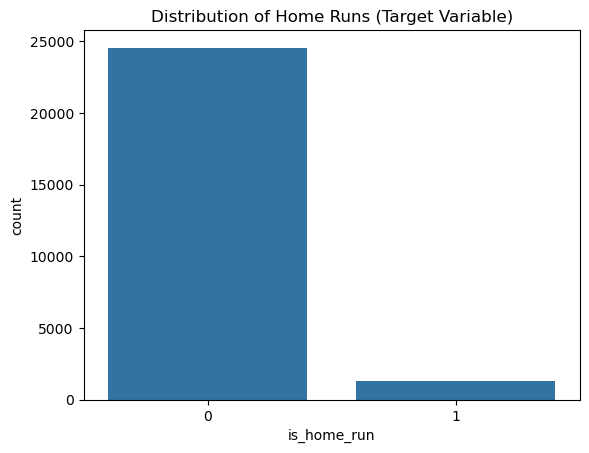

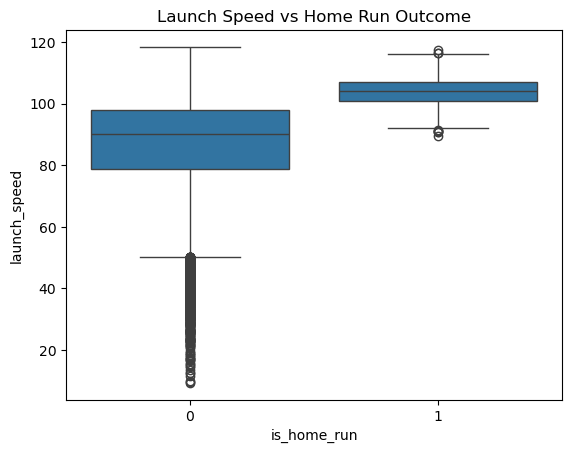

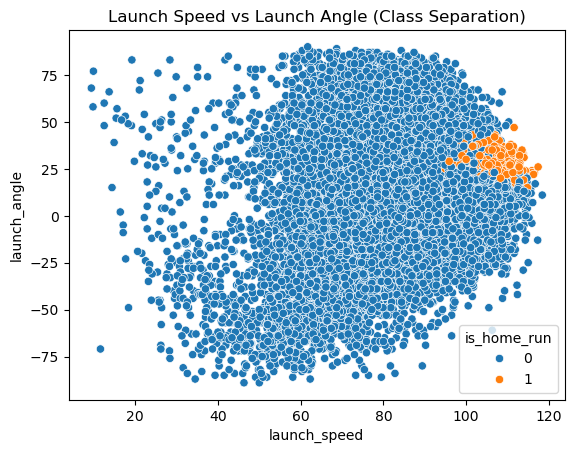

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='is_home_run', data=bball_model)
plt.title("Distribution of Home Runs (Target Variable)")
plt.show()


sns.boxplot(x='is_home_run', y='launch_speed', data=bball_model)
plt.title("Launch Speed vs Home Run Outcome")
plt.show()


sns.scatterplot(
    x='launch_speed',
    y='launch_angle',
    hue='is_home_run',
    data=bball_model
)
plt.title("Launch Speed vs Launch Angle (Class Separation)")
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression
import numpy as np
logmodel= LogisticRegression(penalty=None, max_iter=5000, class_weight='balanced')
logmodel.fit(X_train_scaled, np.ravel(y_train))

features= X.columns
coef= logmodel.coef_[0]

importance= pd.DataFrame({
    'feature': features,
    'coef': coef
        }).sort_values(by='coef', ascending=False)

importance.head(10)

,feature,coef
10,launch_speed,5.614421
11,launch_angle,2.774951
99,bb_type_fly_ball,1.736272
101,bb_type_line_drive,1.698546
29,home_team_NYY,0.238251
31,home_team_PHI,0.217954
91,batter_team_SD,0.205309
13,home_team_BAL,0.175563
88,batter_team_OAK,0.157140
8,plate_z,0.153730


In [12]:
importance.tail(10)

,feature,coef
98,batter_team_WSH,-0.156923
75,batter_team_CLE,-0.169474
104,bearing_right,-0.169541
9,pitch_mph,-0.203388
72,batter_team_BOS,-0.212916
41,away_team_ATL,-0.214244
103,bearing_left,-0.282890
30,home_team_OAK,-0.333883
102,bb_type_popup,-1.712906
100,bb_type_ground_ball,-2.069196


In [13]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score

log_pred= logmodel.predict(X_test_scaled)
log_prob= logmodel.predict_proba(X_test_scaled)[:,1]

print("LR model \n", metrics.confusion_matrix(np.ravel(y_test), log_pred))
print("LR model accuracy:", metrics.accuracy_score(np.ravel(y_test), log_pred))
print("LR model precision:", metrics.precision_score(np.ravel(y_test), log_pred))
print("LR model recall:", metrics.recall_score(np.ravel(y_test), log_pred))
print("LR F1 Score:", metrics.f1_score(y_test, log_pred))
print("LR ROC AUC:", metrics.roc_auc_score(y_test, log_prob))

LR model 
 [[6466  899]
 [  35  360]]
LR model accuracy: 0.8796391752577319
LR model precision: 0.28594122319301035
LR model recall: 0.9113924050632911
LR F1 Score: 0.43530834340991537
LR ROC AUC: 0.9517220517844406


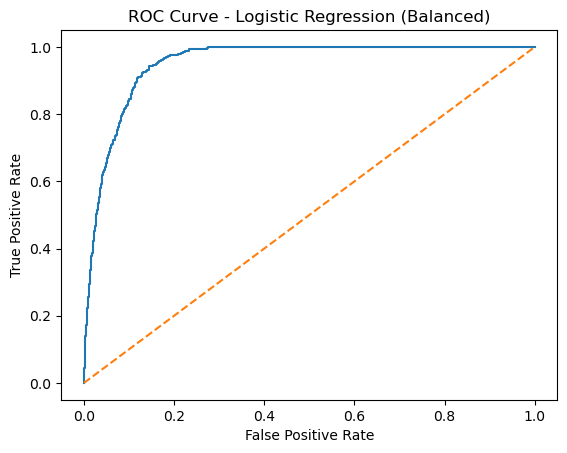

In [14]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, log_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Logistic Regression (Balanced)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [15]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logmodel,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("CV AUC scores:", cv_scores)
print("Mean CV AUC:", cv_scores.mean())

CV AUC scores: [0.9506688  0.95552397 0.95291173 0.95772033 0.95234402]
Mean CV AUC: 0.9538337682625928
